In [88]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import os

In [89]:
def generate_time_series(batch_size, n_step):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_step)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))  
    series += 0.1 * (np.random.rand(batch_size, n_step) - 0.5) 
    return series[..., np.newaxis].astype(np.float32)

In [90]:
nstep = 50
series = generate_time_series(10000, nstep + 1)
X_train, y_train = series[:7000, :nstep], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :nstep], series[7000:9000, -1]
X_test, y_test = series[9000:, :nstep], series[9000:, -1]

In [91]:
Ypred = X_valid[:,-1]
np.mean(keras.losses.mean_squared_error(y_valid, Ypred).numpy())

0.020245474

In [92]:
epochs = 10
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[nstep, 1]),
    keras.layers.Dense(1)
])
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.compile(loss=keras.losses.mean_squared_error, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2757 - val_loss: 0.0900
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - loss: 0.0702 - val_loss: 0.0297
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 0.0263 - val_loss: 0.0141
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - loss: 0.0132 - val_loss: 0.0096
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 0.0095 - val_loss: 0.0078
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.0077 - val_loss: 0.0070
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 0.0068 - val_loss: 0.0065
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 0.0066 - val_loss: 0.0061
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.0060 - val_loss: 0.0057
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 0.0056 - val_loss: 0.0054


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step


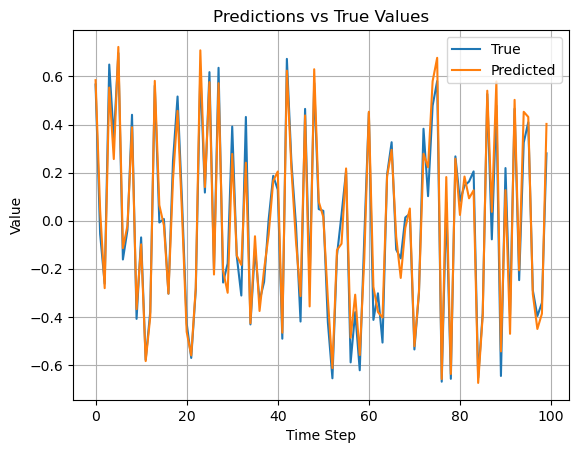

0.0053596226

In [94]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mean_squared_error(y_valid, y_pred).numpy())

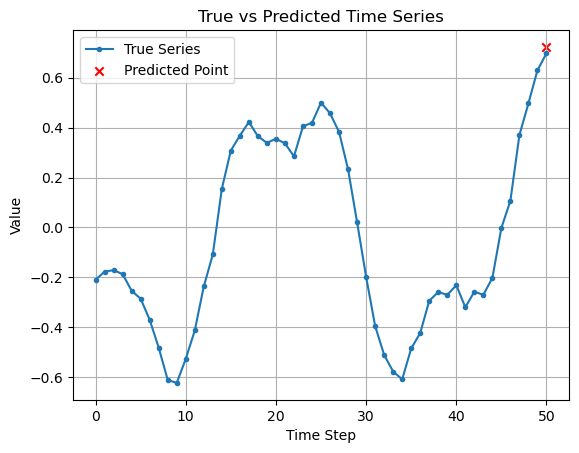

In [95]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

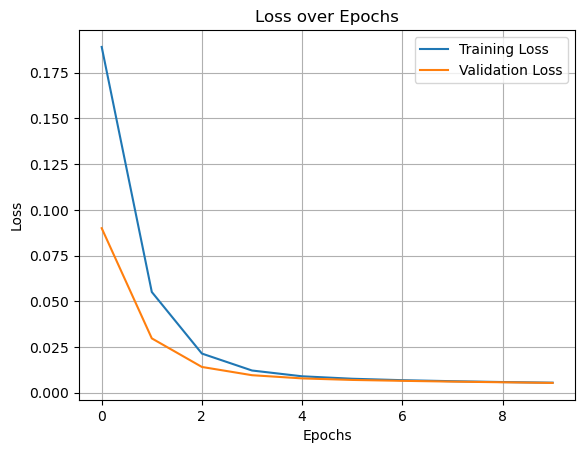

In [96]:
def plot_results(history):
       
    # Plot loss
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_results(history)

# RNN

In [97]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1]),
])
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_22 (SimpleRNN)       │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.compile(loss=keras.losses.mean_squared_error, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2199 - val_loss: 0.0494
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0324 - val_loss: 0.0118
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0117 - val_loss: 0.0112
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0112 - val_loss: 0.0112
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0112 - val_loss: 0.0113
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0110 - val_loss: 0.0113
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - val_loss: 0.0113
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0116 - val_loss: 0.0114
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0115 - val_loss: 0.0111
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0110 - val_loss: 0.0111


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


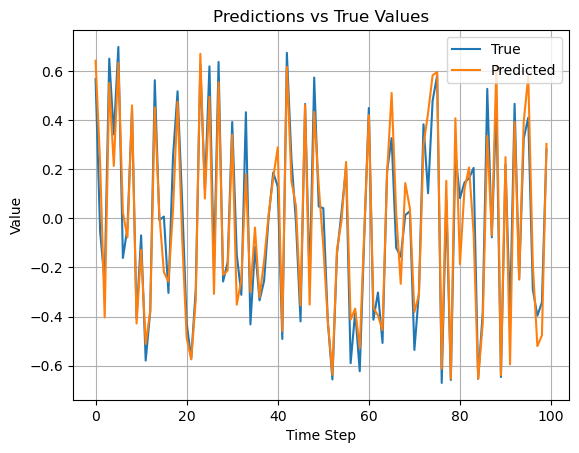

0.011137047

In [99]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mean_squared_error(y_valid, y_pred).numpy())

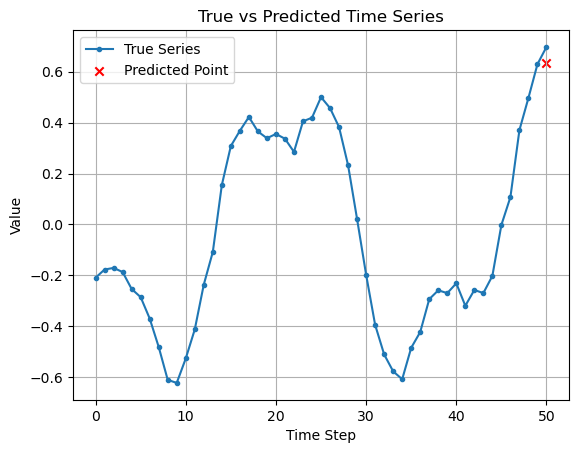

In [100]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

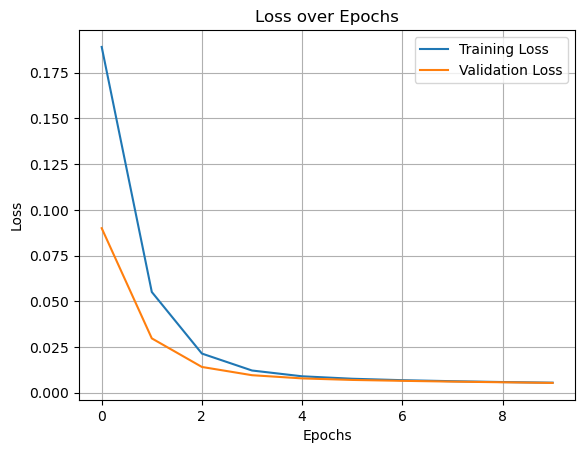

In [101]:
plot_results(history)

In [102]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_23 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_24 (SimpleRNN)       │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.compile(loss=keras.losses.mean_squared_error, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0203 - val_loss: 0.0038
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0036 - val_loss: 0.0045


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


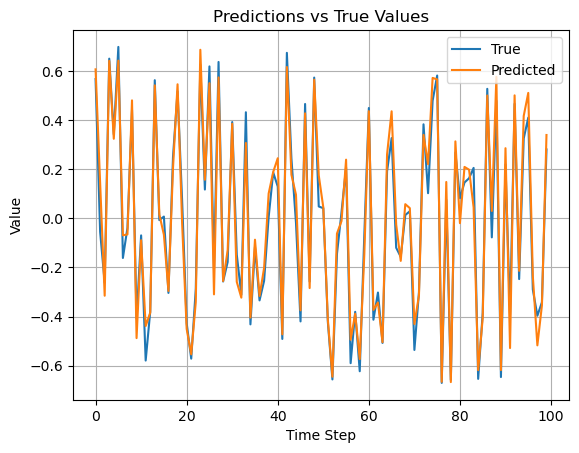

0.0044516386

In [104]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mean_squared_error(y_valid, y_pred).numpy())

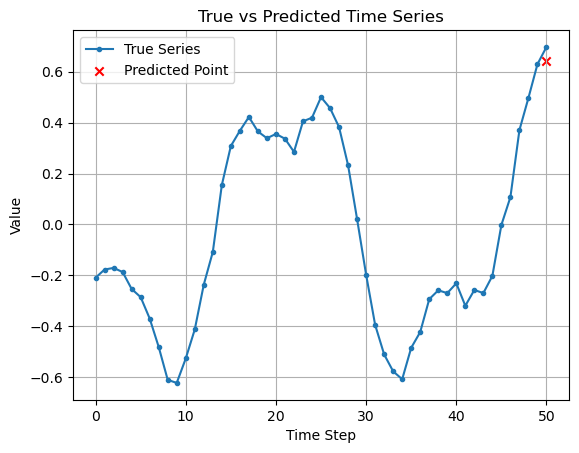

In [105]:
plt.plot(np.hstack((X_valid[5,:,0],y_valid[5])),marker = '.', label='True Series')
plt.scatter([nstep], y_pred[5], marker = 'x',color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

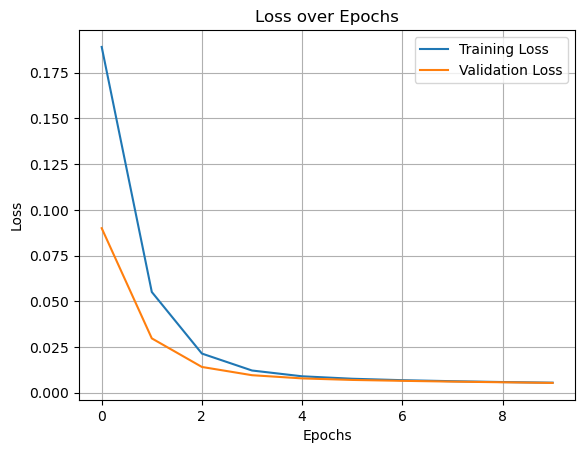

In [106]:
plot_results(history)

In [107]:
series = generate_time_series(10000, nstep + 10)
X_train, y_train = series[:7000, :nstep], series[:7000, -10:, 0]
X_valid, y_valid = series[7000:9000, :nstep], series[7000:9000, -10:, 0]
X_test, y_test = series[9000:, :nstep], series[9000:, -10:, 0]

In [108]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_25 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_26 (SimpleRNN)       │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.compile(loss=keras.losses.mean_squared_error, 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, y_train, epochs=epochs,validation_data=(X_valid, y_valid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0640 - val_loss: 0.0311
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0318 - val_loss: 0.0267
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0309 - val_loss: 0.0339
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0339 - val_loss: 0.0287
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0301 - val_loss: 0.0247
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0299 - val_loss: 0.0315
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0264 - val_loss: 0.0261
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0233 - val_loss: 0.0216
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0234 - val_loss: 0.0184
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0195 - val_loss: 0.0182


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


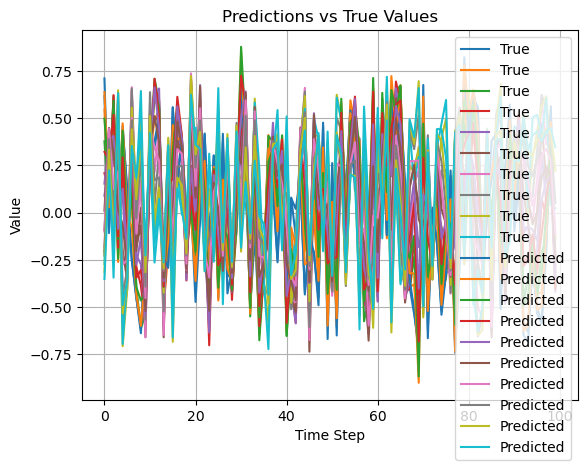

0.01817012

In [110]:
y_pred = model.predict(X_valid)
plt.plot(y_valid[:100], label='True')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Predictions vs True Values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
np.mean(keras.losses.mean_squared_error(y_valid, y_pred).numpy())

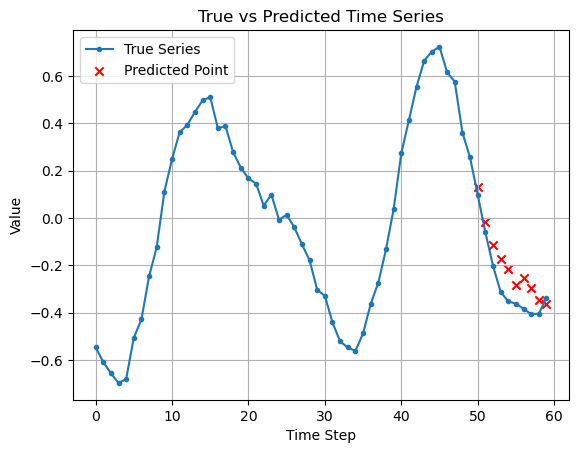

In [111]:
plt.plot(np.hstack((X_valid[5,:,0], y_valid[5])), marker='.', label='True Series')
plt.scatter(np.arange(nstep, nstep + 10), y_pred[5, :], marker='x', color='red', label='Predicted Point')
plt.title('True vs Predicted Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

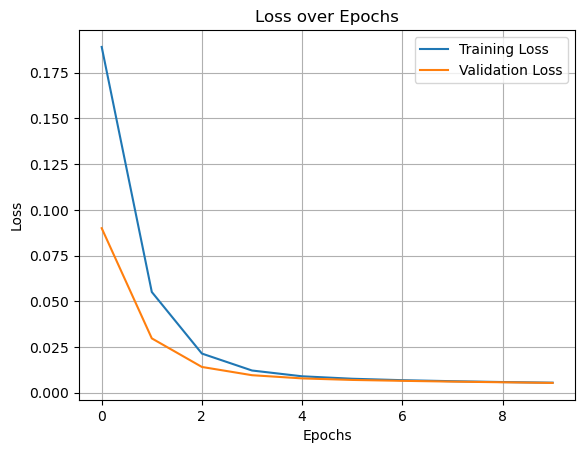

In [112]:
plot_results(history)

# Sequence to Sequence Model

In [113]:
Y = np.empty((10000, nstep,10))
for step_ahead in range (1, 10+1):
    Y[:,:, step_ahead-1] = series[:, step_ahead:step_ahead + nstep, 0]
Ytrain = Y[:7000]
Yvalid = Y[7000:9000]
Ytest = Y[9000:]

In [114]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.summary()


def last_time_step_mse(Ytrue, Ypred):
    return keras.metrics.mean_squared_error(Ytrue[:,-1], Ypred[:, -1])

model.compile(loss=keras.losses.MeanSquaredError(), 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, Ytrain, epochs=epochs,validation_data=(X_valid, Yvalid))

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_27 (SimpleRNN)       │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_28 (SimpleRNN)       │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470 (5.74 KB)

 Trainable params: 1,470 (5.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0743 - val_loss: 0.0420
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0407 - val_loss: 0.0348
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0355 - val_loss: 0.0401
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0305 - val_loss: 0.0278
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0279 - val_loss: 0.0271
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0261 - val_loss: 0.0235
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0234 - val_loss: 0.0235
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0216 - val_loss: 0.0239
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0213 - val_loss: 0.0211
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0208 - val_loss: 0.0199


In [115]:
Ypred = model.predict(X_valid)
print(np.mean(keras.losses.mean_squared_error(Yvalid, Ypred).numpy()))
print(np.mean(last_time_step_mse(Yvalid, Ypred).numpy()))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
0.019867487
0.0074457643


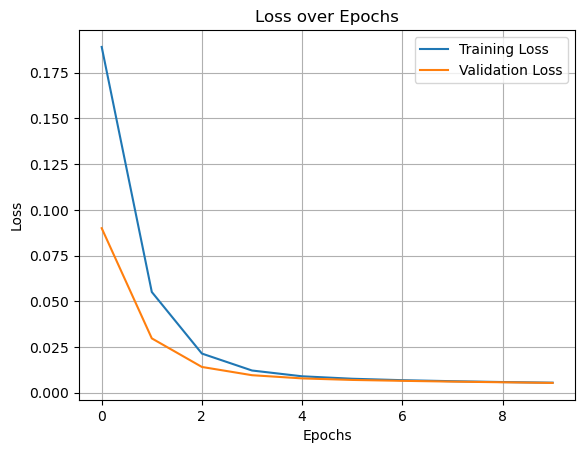

In [116]:
plot_results(history)

# LSTM Network

In [117]:
model = keras.Sequential([
    keras.layers.Input(shape=(1,1)),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 20)          │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 20)          │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 1, 10)          │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
model.compile(loss=keras.losses.MeanSquaredError(), 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, Ytrain, epochs=epochs,validation_data=(X_valid, Yvalid))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0653 - val_loss: 0.0297
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0286 - val_loss: 0.0229
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0221 - val_loss: 0.0194
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0189 - val_loss: 0.0178
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0170 - val_loss: 0.0166
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0161 - val_loss: 0.0158
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0155 - val_loss: 0.0157
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0151 - val_loss: 0.0150
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0148 - val_loss: 0.0150
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0145 - val_loss: 0.0145


In [119]:
Ypred = model.predict(X_valid)
print(np.mean(keras.losses.mean_squared_error(Yvalid, Ypred).numpy()))
print(np.mean(last_time_step_mse(Yvalid, Ypred).numpy()))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
0.014528049
0.003074171


# Combining Convolutional Layer with RNN

In [120]:
model = keras.models.Sequential([
    #keras.layers.Input(shape = (4,1,1)),
    keras.layers.Conv1D(filters=20 , kernel_size=4, strides=2, padding='valid', input_shape= [None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))

])
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, None, 20)       │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, None, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, None, 10)       │           210 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,350 (20.90 KB)

 Trainable params: 5,350 (20.90 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model.compile(loss=keras.losses.MeanSquaredError(), 
              optimizer=keras.optimizers.Adam(learning_rate=1e-2))
model.fit(X_train, Ytrain[:,3::2], epochs=epochs,validation_data=(X_valid, Yvalid[:,3::2]))

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0576 - val_loss: 0.0240
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0219 - val_loss: 0.0172
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0163 - val_loss: 0.0150
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0144 - val_loss: 0.0146
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0138 - val_loss: 0.0128
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0129 - val_loss: 0.0127
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0125 - val_loss: 0.0121
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0123 - val_loss: 0.0120
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0115 - val_loss: 0.0119


In [122]:
Ypred = model.predict(X_valid)
print(np.mean(keras.losses.mean_squared_error(Yvalid[:,3::2], Ypred).numpy()))
print(np.mean(last_time_step_mse(Yvalid[:,3::2], Ypred).numpy()))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
0.01192094
0.0040114755
